# Notebook 6 : Composite Risk Intelligence -->
 ## Overview
This notebook develops a Composite RoadScape Risk Score by combining multiple accident indicators instead of relying on accident count alone. The score considers accident frequency, average casualties, severe accidents, traffic density, and adverse weather conditions to identify high-risk states.

## Objectives
- Build a Composite RoadScape Risk Score.
- Compare states using multiple risk indicators.
- Classify states into Low, Medium and High Risk.
- Generate automated safety recommendations.
- Support data-driven road safety planning.

## Business Questions
1. Which states have the highest overall accident risk?
2. Which factors contribute most to accident risk?
3. Which states should be prioritized?
4. What recommendations can improve road safety?

In [82]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
pd.set_option("display.max_colwidth", None)

In [84]:
df = pd.read_excel("indian_roads_dataset21.xlsx")

## Analysis 1
### Business Question
How can multiple accident indicators be combined into a single RoadScape Risk Score?

In [85]:
risk_df = (
    df.groupby("state")
    .agg(Total_Accidents=("state","count"),Avg_Casualties=("casualties","mean"),

        Severe_Accidents=(
            "accident_severity",
            lambda x: (x=="fatal").sum()
        ),

        High_Traffic=(
            "traffic_density",
            lambda x: (x=="high").sum()
        ),

        Bad_Weather=(
            "weather",
            lambda x: x.isin(
                ["rain","fog"]
            ).sum()
        ),

        Poor_visibility=(
            "visibility",
            lambda x: (x=="low").sum()
        )
    )

    .reset_index()
)

risk_df

,state,Total_Accidents,Avg_Casualties,Severe_Accidents,High_Traffic,Bad_Weather,Poor_visibility
0,Delhi,2433,1.715988,382,909,1607,1156
1,Karnataka,2438,1.693191,384,842,1620,1232
2,Maharashtra,5009,1.740068,757,1730,3304,2520
3,Punjab,2577,1.698487,378,886,1765,1317
4,Tamil Nadu,2575,1.773592,371,921,1701,1277
5,Telangana,2409,1.684516,338,849,1643,1224
6,West Bengal,2559,1.761626,377,897,1670,1261


### Why Normalize?

Each factor has a different scale. Therefore, every indicator is converted into a common 0–100 scale before calculating the final Composite Risk Score.

In [116]:
columns=["Total_Accidents",
         "Avg_Casualties",
         "Severe_Accidents",
         "High_Traffic",
         "Bad_Weather",
         "Poor_visibility"]

for col in columns:
    risk_df[col+"_Score"] = (risk_df[col]/risk_df[col].max())*100

### Composite Risk Score Formula

The Composite RoadScape Risk Score is calculated using weighted indicators.

- Accident Frequency → 30%
- Average Casualties → 25%
- Severe Accidents → 20%
- High Traffic Density → 10%
- Poor Visibility → 10% 
- Bad Weather → 5%

In [117]:
risk_df["Composite_Risk_Score"] = (

      0.30 * risk_df["Total_Accidents_Score"]

    + 0.25 * risk_df["Avg_Casualties_Score"]

    + 0.20 * risk_df["Severe_Accidents_Score"]

    + 0.10 * risk_df["High_Traffic_Score"]

    + 0.10 * risk_df["Poor_visibility_Score"]

    + 0.05 * risk_df["Bad_Weather_Score"]

).round(2)

### Observation
- Multiple accident indicators have been successfully combined into a single Composite RoadScape Risk Score.
- Normalization ensures fair comparison between different indicators. -->
### Business Insight
A composite score provides a more realistic assessment of road safety risk than relying on accident count alone.

## Analysis 2
### Business Question
Which states have the highest Composite RoadScape Risk Score?

In [118]:
risk_df = risk_df.sort_values(by="Composite_Risk_Score",ascending=False).reset_index(drop=True)
risk_df

,state,Total_Accidents,Avg_Casualties,Severe_Accidents,High_Traffic,Bad_Weather,Poor_visibility,Total_Accidents_Score,Avg_Casualties_Score,Severe_Accidents_Score,High_Traffic_Score,Bad_Weather_Score,Poor_visibility_Score,Composite_Risk_Score,Rank,Risk_Level,Recommendation
0,Maharashtra,5009,1.740068,757,1730,3304,2520,100.000000,98.109805,100.000000,100.000000,100.000000,100.000000,99.53,1,High,"Increase traffic surveillance, improve road infrastructure, and strengthen emergency response."
1,Tamil Nadu,2575,1.773592,371,921,1701,1277,51.407467,100.000000,49.009247,53.236994,51.483051,50.674603,63.19,2,High,"Increase traffic surveillance, improve road infrastructure, and strengthen emergency response."
2,West Bengal,2559,1.761626,377,897,1670,1261,51.088042,99.325290,49.801849,51.849711,50.544794,50.039683,62.83,3,Medium,"Improve traffic monitoring, road maintenance, and conduct public awareness campaigns."
3,Punjab,2577,1.698487,378,886,1765,1317,51.447395,95.765339,49.933950,51.213873,53.420097,52.261905,62.38,4,Medium,"Improve traffic monitoring, road maintenance, and conduct public awareness campaigns."
4,Delhi,2433,1.715988,382,909,1607,1156,48.572569,96.752143,50.462351,52.543353,48.638015,45.873016,61.13,5,Medium,"Improve traffic monitoring, road maintenance, and conduct public awareness campaigns."
5,Karnataka,2438,1.693191,384,842,1620,1232,48.672390,95.466766,50.726552,48.670520,49.031477,48.888889,60.82,6,Low,Maintain current safety measures and continue regular monitoring.
6,Telangana,2409,1.684516,338,849,1643,1224,48.093432,94.977660,44.649934,49.075145,49.727603,48.571429,59.35,7,Low,Maintain current safety measures and continue regular monitoring.


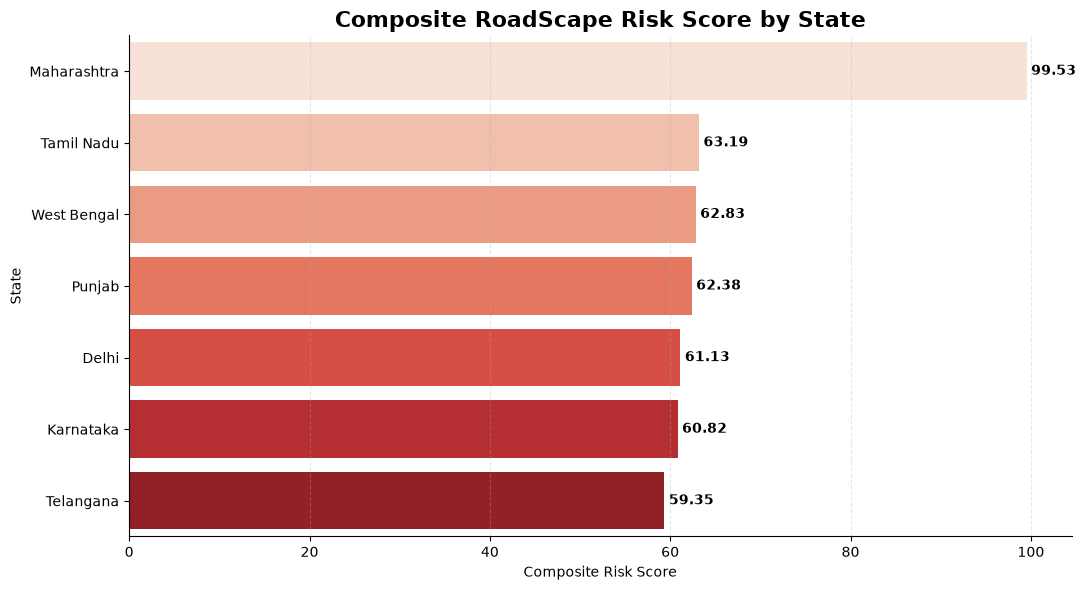

In [119]:
plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=risk_df,
    x="Composite_Risk_Score",
    y="state",
    hue="state",
    palette="Reds",
    legend=False
)

plt.title(
    "Composite RoadScape Risk Score by State",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Composite Risk Score")
plt.ylabel("State")

plt.grid(axis="x",linestyle="--",alpha=0.3)

for i,v in enumerate(risk_df["Composite_Risk_Score"]):

    ax.text(
        v+0.5,
        i,
        f"{v:.2f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

sns.despine()

plt.tight_layout()

plt.show()

### Observation
- Maharashtra has the highest Composite RoadScape Risk Score among all states.
- The ranking highlights states where multiple risk indicators combine to produce higher overall road safety risk.

### Business Insight
Instead of relying on accident count alone, the Composite RoadScape Risk Score combines multiple indicators to provide a holistic assessment of road safety risk.

# ## Analysis 3
### Business Question
How can states be classified into different risk levels?

In [120]:
risk_df["Rank"] = range(1,len(risk_df)+1)

def risk_level(rank):
    if rank<=2:
        return "High"
    elif rank<=5:
        return "Medium"
    else:
        return "Low"
risk_df["Risk_Level"] = risk_df["Rank"].apply(risk_level)
risk_df

,state,Total_Accidents,Avg_Casualties,Severe_Accidents,High_Traffic,Bad_Weather,Poor_visibility,Total_Accidents_Score,Avg_Casualties_Score,Severe_Accidents_Score,High_Traffic_Score,Bad_Weather_Score,Poor_visibility_Score,Composite_Risk_Score,Rank,Risk_Level,Recommendation
0,Maharashtra,5009,1.740068,757,1730,3304,2520,100.000000,98.109805,100.000000,100.000000,100.000000,100.000000,99.53,1,High,"Increase traffic surveillance, improve road infrastructure, and strengthen emergency response."
1,Tamil Nadu,2575,1.773592,371,921,1701,1277,51.407467,100.000000,49.009247,53.236994,51.483051,50.674603,63.19,2,High,"Increase traffic surveillance, improve road infrastructure, and strengthen emergency response."
2,West Bengal,2559,1.761626,377,897,1670,1261,51.088042,99.325290,49.801849,51.849711,50.544794,50.039683,62.83,3,Medium,"Improve traffic monitoring, road maintenance, and conduct public awareness campaigns."
3,Punjab,2577,1.698487,378,886,1765,1317,51.447395,95.765339,49.933950,51.213873,53.420097,52.261905,62.38,4,Medium,"Improve traffic monitoring, road maintenance, and conduct public awareness campaigns."
4,Delhi,2433,1.715988,382,909,1607,1156,48.572569,96.752143,50.462351,52.543353,48.638015,45.873016,61.13,5,Medium,"Improve traffic monitoring, road maintenance, and conduct public awareness campaigns."
5,Karnataka,2438,1.693191,384,842,1620,1232,48.672390,95.466766,50.726552,48.670520,49.031477,48.888889,60.82,6,Low,Maintain current safety measures and continue regular monitoring.
6,Telangana,2409,1.684516,338,849,1643,1224,48.093432,94.977660,44.649934,49.075145,49.727603,48.571429,59.35,7,Low,Maintain current safety measures and continue regular monitoring.


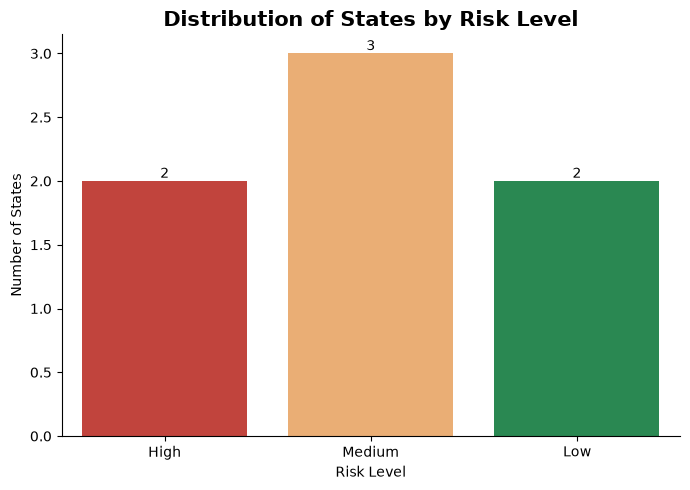

In [121]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=risk_df,
    x="Risk_Level",
    order=["High","Medium","Low"],
    hue="Risk_Level",
    palette=["#d73027","#fdae61","#1a9850"],
    legend=False
)

plt.title(
    "Distribution of States by Risk Level",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of States")

for container in ax.containers:
    ax.bar_label(container)

sns.despine()

plt.tight_layout()

plt.show()

### Observation
- States have been categorized into High, Medium and Low Risk groups based on their Composite Risk Score ranking.
- This classification makes the interpretation of risk simpler and supports prioritization. -->

### Business Insight
Risk categorization enables policymakers to allocate resources more efficiently by focusing on the highest-risk regions first.

## Analysis 4
### Business Question
What safety recommendations can be generated for each state based on its risk level?

In [122]:
def recommendation(level):
    if level=="High":
        return "Increase traffic surveillance, improve road infrastructure, and strengthen emergency response."
    elif level=="Medium":
        return "Improve traffic monitoring, road maintenance, and conduct public awareness campaigns."
    else:
        return "Maintain current safety measures and continue regular monitoring."

risk_df["Recommendation"] = risk_df["Risk_Level"].apply(recommendation)
risk_df[
    [
        "Rank",
        "state",
        "Composite_Risk_Score",
        "Risk_Level",
        "Recommendation"
    ]
]

,Rank,state,Composite_Risk_Score,Risk_Level,Recommendation
0,1,Maharashtra,99.53,High,"Increase traffic surveillance, improve road infrastructure, and strengthen emergency response."
1,2,Tamil Nadu,63.19,High,"Increase traffic surveillance, improve road infrastructure, and strengthen emergency response."
2,3,West Bengal,62.83,Medium,"Improve traffic monitoring, road maintenance, and conduct public awareness campaigns."
3,4,Punjab,62.38,Medium,"Improve traffic monitoring, road maintenance, and conduct public awareness campaigns."
4,5,Delhi,61.13,Medium,"Improve traffic monitoring, road maintenance, and conduct public awareness campaigns."
5,6,Karnataka,60.82,Low,Maintain current safety measures and continue regular monitoring.
6,7,Telangana,59.35,Low,Maintain current safety measures and continue regular monitoring.


In [123]:
def risk_color(val):

    if val == "High":
        return "background-color:#dc3545; color:white; font-weight:bold;"

    elif val == "Medium":
        return "background-color:#ffc107; color:black; font-weight:bold;"

    else:
        return "background-color:#28a745; color:white; font-weight:bold;"


def rank_color(val):

    if val <= 2:
        return "background-color:#ff4d4d; color:white; font-weight:bold;"

    elif val <= 5:
        return "background-color:#ffd966; color:black; font-weight:bold;"

    else:
        return "background-color:#7ed957; color:white; font-weight:bold;"


risk_df[
    [
        "Rank",
        "state",
        "Composite_Risk_Score",
        "Risk_Level",
        "Recommendation"
    ]
].style\
.background_gradient(
    subset=["Composite_Risk_Score"],
    cmap="Reds"
)\
.map(
    rank_color,
    subset=["Rank"]
)\
.map(
    risk_color,
    subset=["Risk_Level"]
)\
.set_properties(
    subset=["Recommendation"],
    **{
        "text-align":"left",
        "white-space":"normal"
    }
)\
.set_caption(
    "RoadScape Composite Risk Assessment Report"
)

,Rank,state,Composite_Risk_Score,Risk_Level,Recommendation
0,1,Maharashtra,99.530000,High,"Increase traffic surveillance, improve road infrastructure, and strengthen emergency response."
1,2,Tamil Nadu,63.190000,High,"Increase traffic surveillance, improve road infrastructure, and strengthen emergency response."
2,3,West Bengal,62.830000,Medium,"Improve traffic monitoring, road maintenance, and conduct public awareness campaigns."
3,4,Punjab,62.380000,Medium,"Improve traffic monitoring, road maintenance, and conduct public awareness campaigns."
4,5,Delhi,61.130000,Medium,"Improve traffic monitoring, road maintenance, and conduct public awareness campaigns."
5,6,Karnataka,60.820000,Low,Maintain current safety measures and continue regular monitoring.
6,7,Telangana,59.350000,Low,Maintain current safety measures and continue regular monitoring.


### Observation
- High-risk states require immediate intervention.
- Medium-risk states require continuous monitoring and preventive measures.
- Low-risk states should maintain existing safety strategies.

### Business Insight
The recommendation engine transforms analytical findings into practical actions, enabling authorities to implement targeted road safety measures based on each state's risk level.

## Analysis 5
### Business Question
How much does each factor contribute to the Composite RoadScape Risk Score?

In [124]:
weights = pd.DataFrame({
    "Risk Factor":[
        "Accident Frequency",
        "Average Casualties",
        "Severe Accidents",
        "High Traffic Density",
        "Poor Visibility",
        "Adverse Weather"
    ],
    "Weight (%)":[30,25,20,10,10,5]
})
weights

,Risk Factor,Weight (%)
0,Accident Frequency,30
1,Average Casualties,25
2,Severe Accidents,20
3,High Traffic Density,10
4,Poor Visibility,10
5,Adverse Weather,5


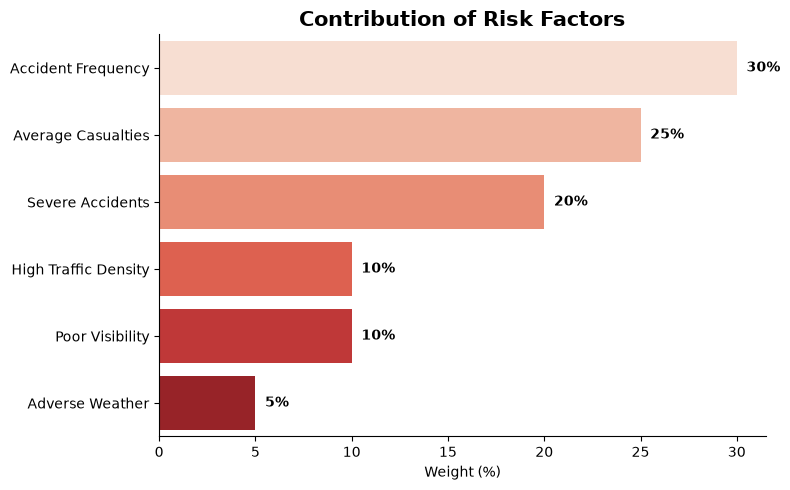

In [125]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=weights,
    x="Weight (%)",
    y="Risk Factor",
    hue="Risk Factor",
    palette="Reds",
    legend=False
)

plt.title(
    "Contribution of Risk Factors",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Weight (%)")
plt.ylabel("")

for i,v in enumerate(weights["Weight (%)"]):

    ax.text(
        v+0.5,
        i,
        f"{v}%",
        va="center",
        fontweight="bold"
    )

sns.despine()

plt.tight_layout()

plt.show()

# Observation:
Accident Frequency and Average Casualties contribute the most to the Composite Risk Score because they directly represent the frequency and impact of road accidents

# Business Insight:
Understanding factor contributions improves transparency and helps stakeholders interpret how the Composite Risk Score is calculated.

# Notebook Summary
This notebook developed a Composite RoadScape Risk Score by integrating accident frequency, average casualties, severe accidents, traffic density, poor visibility, and adverse weather conditions. States were ranked according to their overall risk, classified into High, Medium, and Low Risk categories, and provided with automated safety recommendations. -->

 # Business Conclusion
The Composite RoadScape Risk Score converts multiple accident indicators into a single business metric for decision-making. By combining accident frequency, severity, traffic conditions, visibility, and weather, RoadScape provides a comprehensive assessment of road safety risk and helps authorities prioritize interventions in high-risk regions.